In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import csv
import time
import copy
from pathlib import Path
from tqdm.notebook import tqdm # Прогресс-бары

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, SubsetRandomSampler, random_split
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split # Для разделения train/val

# --- Настройки для воспроизводимости и окружения ---
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Ограничиваем количество потоков PyTorch
torch.set_num_threads(1) 

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {DEVICE}")

# --- Пути к артефактам ---
BASE_DIR = Path(".") 
ARTIFACTS_DIR = BASE_DIR / "artifacts"
FIGURES_DIR = ARTIFACTS_DIR / "figures"
DATA_ROOT_FOR_TORCHVISION = BASE_DIR / "data"

# Создаем папки
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# --- Параметры обучения (Общие) ---
BATCH_SIZE = 128 
MAX_EPOCHS = 15 # Максимальное число эпох для всех экспериментов
HIDDEN_SIZES_MLP = [512, 256, 128]

# --- Информация о датасете ---
DATASET_NAME = "EMNIST Balanced" 
INPUT_SIZE = 28 * 28 # EMNIST изображения 28x28
NUM_CLASSES = 47 # EMNIST Balanced имеет 47 классов

print("Библиотеки импортированы, папки созданы, глобальные настройки установлены.")

Используемое устройство: cpu
Библиотеки импортированы, папки созданы, глобальные настройки установлены.


100%|██████████| 562M/562M [01:07<00:00, 8.31MB/s] 


Размеры датасетов: Train=90240, Val=22560, Test=18800
Batch size: 128
Количество классов: 47
Пример Batch X shape: torch.Size([128, 1, 28, 28])
Пример Batch y shape: torch.Size([128])
Пример диапазона X_batch: Min=-0.42, Max=2.82
Пример dtype X_batch: torch.float32, y_batch: torch.int64
X_batch device: cpu, y_batch device: cpu


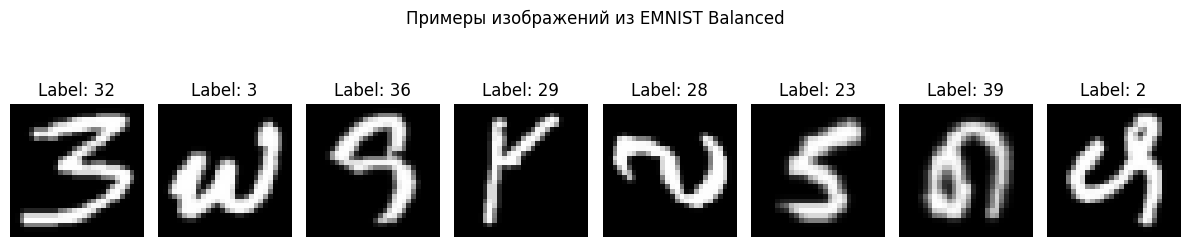

In [2]:
# --- Трансформации ---
transform = transforms.Compose([
    transforms.ToTensor(), # PIL Image -> Tensor, масштабирование [0, 1]
    transforms.Normalize((0.1307,), (0.3081,)) # Стандартная нормализация для EMNIST
])

# --- Загрузка датасета EMNIST Balanced ---
train_full_dataset = datasets.EMNIST(root='./data', split="balanced", train=True, download=True, transform=transform)
test_dataset = datasets.EMNIST(root='./data', split="balanced", train=False, download=True, transform=transform)

# --- Разделение на Train / Val ---
train_size = int(0.8 * len(train_full_dataset))
val_size = len(train_full_dataset) - train_size
generator = torch.Generator().manual_seed(SEED) # Генератор для воспроизводимости split

train_dataset, val_dataset = random_split(
    train_full_dataset, [train_size, val_size], generator=generator
)

# --- Создание DataLoader'ов ---
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# --- Sanity Check (проверка данных) ---
print(f"Размеры датасетов: Train={len(train_dataset)}, Val={len(val_dataset)}, Test={len(test_dataset)}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Количество классов: {NUM_CLASSES}")

# Проверяем shape и диапазон значений одного батча
X_batch, y_batch = next(iter(train_loader)) # Получаем первый батч
print(f"Пример Batch X shape: {X_batch.shape}")
print(f"Пример Batch y shape: {y_batch.shape}")
print(f"Пример диапазона X_batch: Min={X_batch.min().item():.2f}, Max={X_batch.max().item():.2f}")
print(f"Пример dtype X_batch: {X_batch.dtype}, y_batch: {y_batch.dtype}")

# Проверка device
X_batch_dev, y_batch_dev = X_batch.to(DEVICE), y_batch.to(DEVICE)
print(f"X_batch device: {X_batch_dev.device}, y_batch device: {y_batch_dev.device}")

# Визуализация 8 примеров
fig, axes = plt.subplots(1, 8, figsize=(12,3))
for i, ax in enumerate(axes):
    ax.imshow(X_batch[i].cpu().squeeze(), cmap="gray")
    ax.set_title(f"Label: {y_batch[i].item()}")
    ax.axis("off")
plt.suptitle("Примеры изображений из EMNIST Balanced")
plt.tight_layout()
plt.show()

In [3]:
# --- Реализация Модели MLP ---
class MLPClassifier(nn.Module):
    def __init__(self, input_size, hidden_sizes, num_classes, activation_name="ReLU", dropout_p=0.0, use_batchnorm=False):
        super().__init__()
        
        self.flatten = nn.Flatten()
        
        layers = []
        in_features = input_size

        if activation_name == "ReLU":
            activation_cls = nn.ReLU
        else:
            raise ValueError(f"Unsupported activation: {activation_name}")
        
        # Скрытые слои
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(in_features, hidden_size))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(activation_cls())
            if dropout_p > 0:
                layers.append(nn.Dropout(dropout_p))
            in_features = hidden_size
                
        # Выходной слой
        layers.append(nn.Linear(in_features, num_classes))
        
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        x = self.flatten(x)
        logits = self.network(x)
        return logits

# --- Функция для обучения одной эпохи ---
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train() 
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    
    for x_batch, y_batch in tqdm(dataloader, desc="Training"):
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad() 
        logits = model(x_batch)
        loss = criterion(logits, y_batch)
        loss.backward() 
        optimizer.step() 
        
        total_loss += loss.item() * x_batch.size(0)
        total_samples += y_batch.size(0)
        total_correct += (torch.argmax(logits, dim=1) == y_batch).sum().item()
        
    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    return avg_loss, avg_acc

# --- Функция для оценки (валидации/теста) ---
def evaluate_model_performance(model, dataloader, criterion, device):
    model.eval() 
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    
    with torch.no_grad(): 
        for x_batch, y_batch in tqdm(dataloader, desc="Evaluating"):
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            logits = model(x_batch)
            loss = criterion(logits, y_batch)
            
            total_loss += loss.item() * x_batch.size(0)
            total_samples += y_batch.size(0)
            total_correct += (torch.argmax(logits, dim=1) == y_batch).sum().item()
            
    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    return avg_loss, avg_acc

# --- Класс EarlyStopping ---
class EarlyStopping:
    def __init__(self, patience=4, mode='max', min_delta=0.0):
        self.patience = patience
        self.mode = mode
        self.min_delta = min_delta
        self.best_score = None
        self.counter = 0
        self.should_stop = False

    def step(self, current_score):
        if self.best_score is None:
            self.best_score = current_score
            return False

        if (self.mode == 'max' and current_score > self.best_score + self.min_delta) or \
           (self.mode == 'min' and current_score < self.best_score - self.min_delta):
            self.best_score = current_score
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
        return self.should_stop

print("Модель MLP и все вспомогательные функции определены.")

Модель MLP и все вспомогательные функции определены.


In [4]:
# --- Универсальный запуск одного эксперимента ---
RUNS_CSV_PATH = ARTIFACTS_DIR / "runs.csv"

def run_experiment(
    experiment_id,
    dataset_name,
    seed,
    model_config, # Словарь с параметрами для конструктора MLPClassifier
    optimizer_name,
    lr,
    train_loader,
    val_loader,
    test_loader, # Передаем test_loader, если нужен
    device,
    num_epochs=MAX_EPOCHS,
    momentum=0.0,
    weight_decay=0.0,
    use_early_stopping=False,
    early_stopping_patience=4
):
    print(f"\n{'='*10} Запуск эксперимента: {experiment_id} {'='*10}")
    start_time = time.time()

    # Фиксируем seed для этого прогона
    torch.manual_seed(seed)
    np.random.seed(seed)

    # Создаем модель и перемещаем её на DEVICE
    model = MLPClassifier(**model_config).to(device)
    criterion = nn.CrossEntropyLoss()
    
    # Выбор оптимизатора
    if optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    else:
        raise ValueError("Unsupported optimizer type")

    history = {
        'train_loss': [], 'train_acc': [], 
        'val_loss': [], 'val_acc': []
    }
    
    early_stopper = None
    if use_early_stopping:
        early_stopper = EarlyStopping(patience=early_stopping_patience, mode='max') # max для val_accuracy

    best_val_acc = -1.0
    best_val_loss = float('inf')
    best_epoch = 0
    best_state_dict = copy.deepcopy(model.state_dict()) # Сохраняем веса лучшей модели
    
    epochs_trained = 0
    
    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate_model_performance(model, val_loader, criterion, device)
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"  Epoch [{epoch}/{num_epochs}]: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f} | Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")
        
        epochs_trained = epoch

        # Logic for EarlyStopping and saving best model state_dict
        if val_acc > best_val_acc: # Мы отслеживаем best_val_acc
            best_val_acc = val_acc
            best_val_loss = val_loss
            best_epoch = epoch
            best_state_dict = copy.deepcopy(model.state_dict()) # Сохраняем модель на лучшей эпохе
        
        if use_early_stopping:
            stop = early_stopper.step(val_acc) # Передаем val_acc в EarlyStopping
            if stop:
                print(f"  > Early stopping triggered at epoch {epoch}")
                # best_val_acc и best_val_loss уже будут хранить значения лучшей эпохи до остановки
                break
    
    # Загружаем веса лучшей модели (на момент лучшей val_accuracy) перед финальным логированием/тестом
    model.load_state_dict(best_state_dict)

    # Оценка на Test (только для финальной модели E4)
    test_acc_final = None
    if experiment_id == 'E4':
        _, test_acc_final = evaluate_model_performance(model, test_loader, criterion, device)
        print(f"\n[E4 Final Test Score] Test Acc: {test_acc_final:.4f}")


    end_time = time.time()
    total_time_ms = (end_time - start_time) * 1000 # ms

    # Собираем результат для runs.csv
    model_summary_str = f"hidden={model_config['hidden_sizes']}; act={model_config['activation_name']}; dropout={model_config.get('dropout_p', 0.0)}; batchnorm={model_config.get('use_batchnorm', False)}"

    result_entry = {
        "experiment_id": experiment_id,
        "dataset": dataset_name,
        "seed": seed,
        "model_summary": model_summary_str,
        "optimizer": optimizer_name,
        "lr": lr,
        "momentum": momentum,
        "weight_decay": weight_decay,
        "epochs_trained": epochs_trained,
        "best_val_accuracy": best_val_acc,
        "best_val_loss": best_val_loss,
        "best_epoch": best_epoch,
        "test_accuracy_e4": test_acc_final,
        "total_time_ms": total_time_ms,
        "model_obj": model, # Объект модели для сохранения state_dict
        "history": history # История для графиков
    }
    
    return result_entry

In [5]:
# Ячейка 5: Часть A (S08): Регуляризация и переобучение (E1-E4)

print(f"\n{'='*30} ЧАСТЬ A (S08): Регуляризация {'='*30}")

if RUNS_CSV_PATH.exists():
    RUNS_CSV_PATH.unlink()
    print(f"Удален старый {RUNS_CSV_PATH} для чистого запуска.")

BASE_MODEL_CONFIG = { 
    'input_size': INPUT_SIZE, 
    'hidden_sizes': HIDDEN_SIZES_MLP, 
    'num_classes': NUM_CLASSES,
    'activation_name': "ReLU",
    'dropout_p': 0.0,
    'use_batchnorm': False
}
BASE_OPTIMIZER_CONFIG = {'optimizer_type': 'Adam', 'lr': 1e-3, 'momentum': 0.0, 'weight_decay': 0.0}

all_experiment_results = [] # Список для сбора всех результатов прогонов

# E1 (Base) - без регуляризации
result_e1 = run_experiment('E1', DATASET_NAME, SEED, BASE_MODEL_CONFIG, 
                           BASE_OPTIMIZER_CONFIG['optimizer_type'], BASE_OPTIMIZER_CONFIG['lr'], 
                           train_loader, val_loader, test_loader, DEVICE, 
                           num_epochs=MAX_EPOCHS, 
                           momentum=BASE_OPTIMIZER_CONFIG['momentum'], weight_decay=BASE_OPTIMIZER_CONFIG['weight_decay'])
all_experiment_results.append(result_e1)
pd.DataFrame([result_e1]).drop(columns=['model_obj', 'history']).to_csv(RUNS_CSV_PATH, mode='a', header=True, index=False)
print(f"E1 best val acc: {result_e1['best_val_accuracy']:.4f}")

# E2 (Dropout)
config_e2 = BASE_MODEL_CONFIG.copy()
config_e2['dropout_p'] = 0.3 # Добавляем Dropout
result_e2 = run_experiment('E2', DATASET_NAME, SEED, config_e2, 
                           BASE_OPTIMIZER_CONFIG['optimizer_type'], BASE_OPTIMIZER_CONFIG['lr'], 
                           train_loader, val_loader, test_loader, DEVICE, 
                           num_epochs=MAX_EPOCHS, 
                           momentum=BASE_OPTIMIZER_CONFIG['momentum'], weight_decay=BASE_OPTIMIZER_CONFIG['weight_decay'])
all_experiment_results.append(result_e2)
pd.DataFrame([result_e2]).drop(columns=['model_obj', 'history']).to_csv(RUNS_CSV_PATH, mode='a', header=False, index=False)
print(f"E2 best val acc: {result_e2['best_val_accuracy']:.4f}")

# E3 (BatchNorm)
config_e3 = BASE_MODEL_CONFIG.copy()
config_e3['use_batchnorm'] = True # Использование BatchNorm
result_e3 = run_experiment('E3', DATASET_NAME, SEED, config_e3, 
                           BASE_OPTIMIZER_CONFIG['optimizer_type'], BASE_OPTIMIZER_CONFIG['lr'], 
                           train_loader, val_loader, test_loader, DEVICE, 
                           num_epochs=MAX_EPOCHS, 
                           momentum=BASE_OPTIMIZER_CONFIG['momentum'], weight_decay=BASE_OPTIMIZER_CONFIG['weight_decay'])
all_experiment_results.append(result_e3)
pd.DataFrame([result_e3]).drop(columns=['model_obj', 'history']).to_csv(RUNS_CSV_PATH, mode='a', header=False, index=False)
print(f"E3 best val acc: {result_e3['best_val_accuracy']:.4f}")

# E4 (EarlyStopping) - Лучший из E2/E3 + ES
best_of_e2_e3_run = max([result_e2, result_e3], key=lambda x: x['best_val_accuracy'])

final_e4_model_config = BASE_MODEL_CONFIG.copy()
final_e4_model_config['dropout_p'] = best_of_e2_e3_run['model_summary'].split(';')[2].split('=')[1].strip() == '0.3'
final_e4_model_config['use_batchnorm'] = best_of_e2_e3_run['model_summary'].split(';')[3].split('=')[1].strip() == 'True'

result_e4 = run_experiment('E4', DATASET_NAME, SEED, final_e4_model_config, 
                           BASE_OPTIMIZER_CONFIG['optimizer_type'], BASE_OPTIMIZER_CONFIG['lr'], 
                           train_loader, val_loader, test_loader, DEVICE, 
                           num_epochs=MAX_EPOCHS, use_early_stopping=True, early_stopping_patience=4) 
all_experiment_results.append(result_e4)
pd.DataFrame([result_e4]).drop(columns=['model_obj', 'history']).to_csv(RUNS_CSV_PATH, mode='a', header=False, index=False)
print(f"E4 best val acc: {result_e4['best_val_accuracy']:.4f}")

torch.save(result_e4['model_obj'].state_dict(), ARTIFACTS_DIR / "best_model.pt")
print(f"  > Best model for E4 saved with Val Acc: {result_e4['best_val_accuracy']:.4f}")

global fixed_model_config 
fixed_model_config = final_e4_model_config

print("\n--- Часть A завершена. ---")


============================== ЧАСТЬ A (S08): Регуляризация ==============================
Удален старый artifacts/runs.csv для чистого запуска.

========== Запуск эксперимента: E1 ==========


Training:   0%|          | 0/705 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/177 [00:00<?, ?it/s]

  Epoch [1/15]: Train Loss=0.9807, Train Acc=0.7023 | Val Loss=0.6287, Val Acc=0.7965


Training:   0%|          | 0/705 [00:00<?, ?it/s]

...

Training:   0%|          | 0/705 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/177 [00:00<?, ?it/s]

  Epoch [14/15]: Train Loss=0.1841, Train Acc=0.9233 | Val Loss=0.4915, Val Acc=0.8535
  > Early stopping triggered at epoch 14


Evaluating:   0%|          | 0/147 [00:00<?, ?it/s]


[E4 Final Test Score] Test Acc: 0.8501
E4 best val acc: 0.8558
  > Best model for E4 saved with Val Acc: 0.8558

--- Часть A завершена. ---


In [6]:
# Ячейка 6: Часть B (S09): LR, оптимизаторы, weight decay (O1-O3)

print(f"\n{'='*30} ЧАСТЬ B (S09): Оптимизация {'='*30}")

fixed_model_config = final_e4_model_config # Берем конфиг лучшей модели из Части A

# O1 (LR слишком большой)
optimizer_params_o1 = {'optimizer_type': 'Adam', 'lr': 1e-1, 'momentum': 0.0, 'weight_decay': 0.0} 
result_o1 = run_experiment('O1', DATASET_NAME, SEED, fixed_model_config, 
                           optimizer_params_o1['optimizer_type'], optimizer_params_o1['lr'], 
                           train_loader, val_loader, test_loader, DEVICE, 
                           num_epochs=8, 
                           momentum=optimizer_params_o1['momentum'], weight_decay=optimizer_params_o1['weight_decay']) 
all_experiment_results.append(result_o1)
pd.DataFrame([result_o1]).drop(columns=['model_obj', 'history']).to_csv(RUNS_CSV_PATH, mode='a', header=False, index=False)
print(f"O1 best val acc: {result_o1['best_val_accuracy']:.4f}")

# O2 (LR слишком маленький)
optimizer_params_o2 = {'optimizer_type': 'Adam', 'lr': 1e-5, 'momentum': 0.0, 'weight_decay': 0.0} 
result_o2 = run_experiment('O2', DATASET_NAME, SEED, fixed_model_config, 
                           optimizer_params_o2['optimizer_type'], optimizer_params_o2['lr'], 
                           train_loader, val_loader, test_loader, DEVICE, 
                           num_epochs=8, 
                           momentum=optimizer_params_o2['momentum'], weight_decay=optimizer_params_o2['weight_decay']) 
all_experiment_results.append(result_o2)
pd.DataFrame([result_o2]).drop(columns=['model_obj', 'history']).to_csv(RUNS_CSV_PATH, mode='a', header=False, index=False)
print(f"O2 best val acc: {result_o2['best_val_accuracy']:.4f}")

# O3 (SGD+momentum + weight decay)
optimizer_params_o3 = {'optimizer_type': 'SGD', 'lr': 1e-2, 'momentum': 0.9, 'weight_decay': 1e-4}
result_o3 = run_experiment('O3', DATASET_NAME, SEED, fixed_model_config, 
                           optimizer_params_o3['optimizer_type'], optimizer_params_o3['lr'], 
                           train_loader, val_loader, test_loader, DEVICE, 
                           num_epochs=10, 
                           momentum=optimizer_params_o3['momentum'], weight_decay=optimizer_params_o3['weight_decay']) 
all_experiment_results.append(result_o3)
pd.DataFrame([result_o3]).drop(columns=['model_obj', 'history']).to_csv(RUNS_CSV_PATH, mode='a', header=False, index=False)
print(f"O3 best val acc: {result_o3['best_val_accuracy']:.4f}")

print("\n--- Часть B завершена. ---")


============================== ЧАСТЬ B (S09): Оптимизация ==============================

========== Запуск эксперимента: O1 ==========


Training:   0%|          | 0/705 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/177 [00:00<?, ?it/s]

  Epoch [1/8]: Train Loss=1.0891, Train Acc=0.6683 | Val Loss=0.7910, Val Acc=0.7526


Training:   0%|          | 0/705 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/177 [00:00<?, ?it/s]

  Epoch [9/10]: Train Loss=0.2520, Train Acc=0.9032 | Val Loss=0.4483, Val Acc=0.8508


Training:   0%|          | 0/705 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/177 [00:00<?, ?it/s]

  Epoch [10/10]: Train Loss=0.2351, Train Acc=0.9086 | Val Loss=0.4555, Val Acc=0.8500
O3 best val acc: 0.8534

--- Часть B завершена. ---



--- Финальная таблица runs.csv ---


,experiment_id,dataset,seed,model_summary,optimizer,lr,momentum,weight_decay,epochs_trained,best_val_accuracy,best_val_loss,best_epoch,test_accuracy_e4,total_time_ms
0,E1,EMNIST Balanced,42,"hidden=[512, 256, 128]; act=ReLU; dropout=0.0;...",Adam,0.00100,0.0,0.0000,15,0.847385,0.513501,9,NaN,122414.968014
1,E2,EMNIST Balanced,42,"hidden=[512, 256, 128]; act=ReLU; dropout=0.3;...",Adam,0.00100,0.0,0.0000,15,0.854034,0.443241,12,NaN,123276.178122
2,E3,EMNIST Balanced,42,"hidden=[512, 256, 128]; act=ReLU; dropout=0.0;...",Adam,0.00100,0.0,0.0000,15,0.857846,0.495815,15,NaN,121311.908960
3,E4,EMNIST Balanced,42,"hidden=[512, 256, 128]; act=ReLU; dropout=Fals...",Adam,0.00100,0.0,0.0000,14,0.855807,0.451095,10,0.850106,114447.179794
4,O1,EMNIST Balanced,42,"hidden=[512, 256, 128]; act=ReLU; dropout=Fals...",Adam,0.10000,0.0,0.0000,8,0.817465,0.560063,8,NaN,66407.377958
5,O2,EMNIST Balanced,42,"hidden=[512, 256, 128]; act=ReLU; dropout=Fals...",Adam,0.00001,0.0,0.0000,8,0.737500,1.280114,8,NaN,64339.666843
6,O3,EMNIST Balanced,42,"hidden=[512, 256, 128]; act=ReLU; dropout=Fals...",SGD,0.01000,0.9,0.0001,10,0.853413,0.439174,7,NaN,73875.867128


Конфиг лучшей модели (E4) сохранен в artifacts/best_config.json


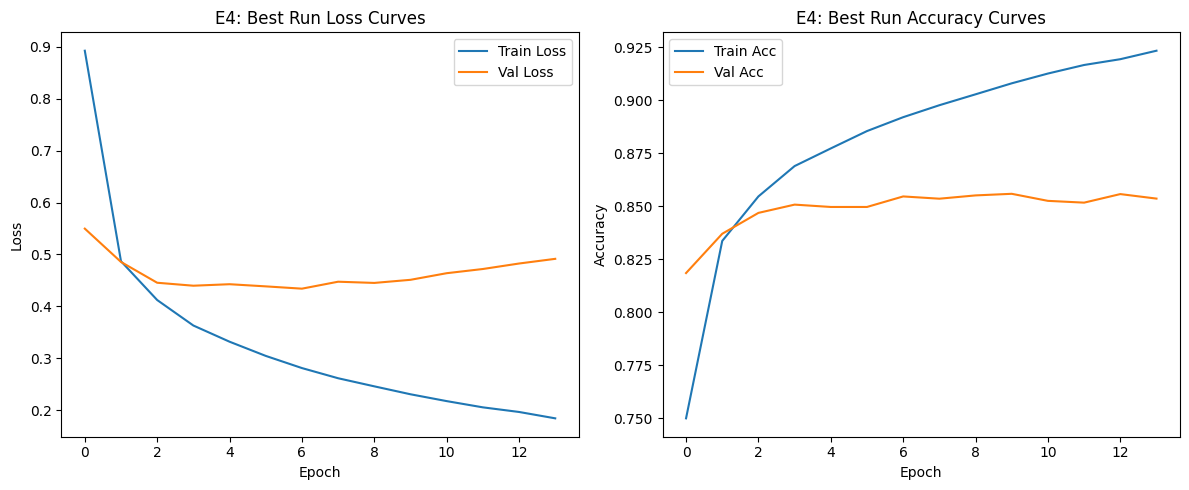

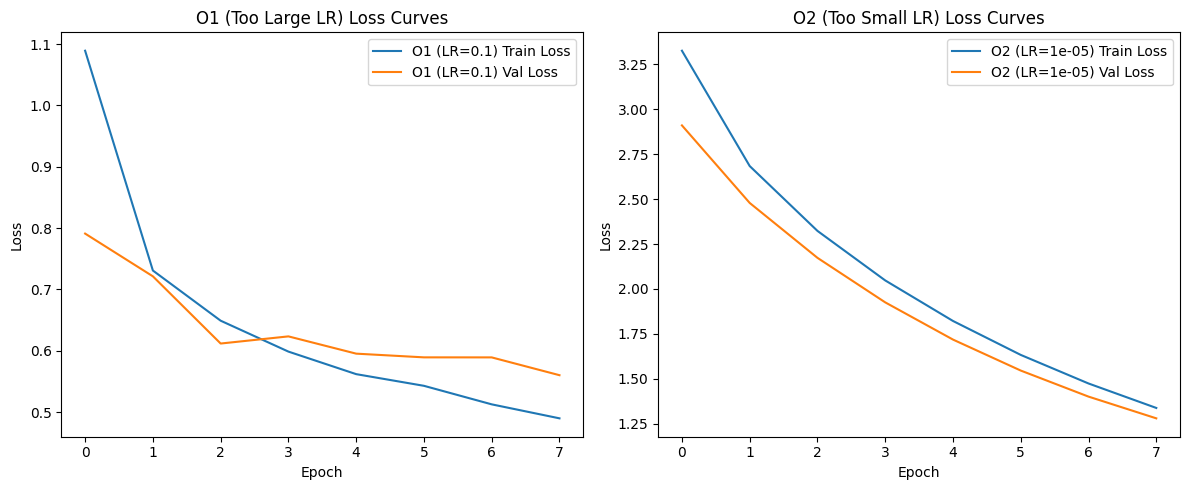

Все артефакты и графики успешно сохранены!


In [7]:
# --- 1. Таблица runs.csv (фин проверка) ---
runs_df_final = pd.read_csv(RUNS_CSV_PATH)
print("\n--- Финальная таблица runs.csv ---")
display(runs_df_final)

# --- 2. Сохранение best_config.json ---
# Пересобираем model_config для best_config.json, чтобы убрать лишние `hidden` и `act`
best_config_data = {
    "experiment_id": result_e4['experiment_id'],
    "dataset": result_e4['dataset'],
    "seed": result_e4['seed'],
    "model_config": {
        "input_size": INPUT_SIZE,
        "hidden_sizes": HIDDEN_SIZES_MLP, 
        "num_classes": NUM_CLASSES,
        "activation_name": "ReLU", 
        "dropout_p": final_e4_model_config.get('dropout_p', 0.0),
        "use_batchnorm": final_e4_model_config.get('use_batchnorm', False)
    },
    "optimizer": result_e4['optimizer'],
    "lr": result_e4['lr'],
    "momentum": result_e4['momentum'],
    "weight_decay": result_e4['weight_decay'],
    "early_stopping": {"enabled": True, "patience": 4}, 
    "epochs_trained": result_e4['epochs_trained'],
    "best_val_accuracy": result_e4['best_val_accuracy'],
    "best_val_loss": result_e4['best_val_loss']
}
with open(ARTIFACTS_DIR / "best_config.json", "w") as f:
    json.dump(best_config_data, f, indent=4)
print(f"Конфиг лучшей модели (E4) сохранен в {ARTIFACTS_DIR / 'best_config.json'}")

# --- 3. Графики кривых обучения ---

# Кривые лучшего прогона (E4)
history_e4 = result_e4['history']
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_e4['train_loss'], label='Train Loss')
plt.plot(history_e4['val_loss'], label='Val Loss')
plt.title(f"E4: Best Run Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_e4['train_acc'], label='Train Acc')
plt.plot(history_e4['val_acc'], label='Val Acc')
plt.title(f"E4: Best Run Accuracy Curves")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "curves_best.png")
plt.show()

# Кривые "плохих LR" (O1 и O2)
history_o1 = result_o1['history']
history_o2 = result_o2['history']
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_o1['train_loss'], label=f"O1 (LR={optimizer_params_o1['lr']}) Train Loss")
plt.plot(history_o1['val_loss'], label=f"O1 (LR={optimizer_params_o1['lr']}) Val Loss")
plt.title("O1 (Too Large LR) Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_o2['train_loss'], label=f"O2 (LR={optimizer_params_o2['lr']}) Train Loss")
plt.plot(history_o2['val_loss'], label=f"O2 (LR={optimizer_params_o2['lr']}) Val Loss")
plt.title("O2 (Too Small LR) Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "curves_lr_extremes.png")
plt.show()

print("Все артефакты и графики успешно сохранены!")